In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [26]:
with open('./code-600000-603000.pkl', 'rb') as f:
    results = pickle.load(f)

In [27]:
is_profit = [p[-1] for p in results]
len(is_profit)

1002

/home/kaboom/.pyenv/versions/3.6.8/lib/python3.6/site-packages/matplotlib/font_manager.py:1331: UserWarning: findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))


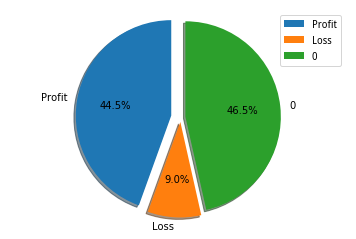

In [28]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font = fm.FontProperties(fname='./font/wqy-microhei.ttc')

labels = 'Profit', 'Loss', '0'

sizes = [0, 0, 0]

for p in is_profit:
    if p > 0:
        sizes[0] += 1
    if p < 0:
        sizes[1] += 1
    else:
        sizes[2] += 1

explode = (0.1, 0.05, 0.05)

fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', 
        shadow=True, startangle=90)
ax1.axis('equal')
plt.legend(prop=font)
plt.show()

(array([8.50180513e-06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.50180513e-06,
        1.70036103e-05, 1.70036103e-05, 2.55054154e-05, 5.95126359e-05,
        8.50180513e-06, 6.80144410e-05, 6.80144410e-05, 1.02021662e-04,
        1.61534297e-04, 3.57075815e-04, 9.60703980e-04, 9.43700369e-04,
        1.02871842e-03, 1.19875452e-03, 7.99169682e-04, 5.01606503e-04,
        4.76101087e-04, 3.23068595e-04, 2.80559569e-04, 1.615342

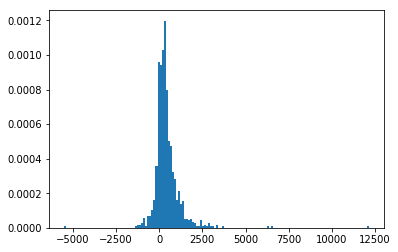

In [35]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font = fm.FontProperties(fname='./font/wqy-microhei.ttc')
n_bins = 150

fig, axs = plt.subplots()
axs.hist(is_profit, bins=n_bins, density=True)

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np


# ===========================================
# 1. 下载数据并解决 MultiIndex → 单层列名
# ===========================================
def get_stock_data(ticker="AAPL", start="2010-01-01"):
    df = yf.download(ticker, start=start)

    # flatten multi-index columns if exists
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    return df


# ===========================================
# 2. 计算全部技术指标
# ===========================================
def compute_technical_indicators(df):

    # ========== 基础行情 ==========
    df["vwap"] = (df["High"] + df["Low"] + df["Close"]) / 3
    df["return_1d"] = df["Close"].pct_change()

    # ========== 均线 ==========
    for w in [5, 10, 20, 50, 200]:
        df[f"MA{w}"] = df["Close"].rolling(window=w).mean()

    # ========== RSI ==========
    delta = df["Close"].diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)

    roll_up = up.rolling(14).mean()
    roll_down = down.rolling(14).mean()

    RS = roll_up / roll_down
    df["RSI14"] = 100 - (100 / (1 + RS))

    # ========== MACD ==========
    ema12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema26 = df["Close"].ewm(span=26, adjust=False).mean()
    df["MACD"] = ema12 - ema26
    df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

    # ========== 布林带 ==========
    df["Std20"] = df["Close"].rolling(20).std()
    df["Boll_up"] = df["MA20"] + 2 * df["Std20"]
    df["Boll_low"] = df["MA20"] - 2 * df["Std20"]

    # ========== ATR ==========
    df["H-L"] = df["High"] - df["Low"]
    df["H-PC"] = (df["High"] - df["Close"].shift(1)).abs()
    df["L-PC"] = (df["Low"] - df["Close"].shift(1)).abs()

    df["TR"] = df[["H-L", "H-PC", "L-PC"]].max(axis=1)
    df["ATR14"] = df["TR"].rolling(14).mean()

    # ========== 量能指标 ==========
    volume = df["Volume"]

    df["MA_volume20"] = volume.rolling(20).mean()
    df["volume_ratio"] = volume / df["MA_volume20"]

    # OBV
    obv = np.where(df["Close"] > df["Close"].shift(1), volume,
            np.where(df["Close"] < df["Close"].shift(1), -volume, 0))
    df["OBV"] = pd.Series(obv, index=df.index).cumsum()

    df = df.dropna()

    return df


# ===========================================
# 3. Normalize 所有特征（-1 到 1）
# ===========================================
def normalize_features(df):
    norm_df = (df - df.mean()) / df.std()
    norm_df = norm_df.clip(-1, 1)  # 限制到[-1,1]
    return norm_df


# ===========================================
# 4. 主函数：得到最终 Observation
# ===========================================
def get_stock_observation(ticker="AAPL", start="2010-01-01"):
    df = get_stock_data(ticker, start)
    df = compute_technical_indicators(df)
    obs = normalize_features(df)
    return obs



In [10]:

obs = get_stock_observation("AAPL")

print("Observation shape:", obs.shape)
print(obs.tail())
obs.to_csv("AAPL_observation.csv")

C:\Users\Bowen Ma\AppData\Local\Temp\ipykernel_3220\1428467426.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start)
[*********************100%***********************]  1 of 1 completed

Observation shape: (3794, 26)
            Close  High  Low  Open    Volume  vwap  return_1d  MA5  MA10  \
Date                                                                       
2025-11-10    1.0   1.0  1.0   1.0 -0.830864   1.0   0.197078  1.0   1.0   
2025-11-11    1.0   1.0  1.0   1.0 -0.804916   1.0   1.000000  1.0   1.0   
2025-11-12    1.0   1.0  1.0   1.0 -0.793311   1.0  -0.422463  1.0   1.0   
2025-11-13    1.0   1.0  1.0   1.0 -0.786925   1.0  -0.165694  1.0   1.0   
2025-11-14    1.0   1.0  1.0   1.0 -0.798604   1.0  -0.170023  1.0   1.0   

            MA20  ...  Boll_up  Boll_low  H-L      H-PC      L-PC        TR  \
Date              ...                                                         
2025-11-10   1.0  ...      1.0       1.0  1.0  1.000000 -0.145059  1.000000   
2025-11-11   1.0  ...      1.0       1.0  1.0  1.000000 -0.375731  1.000000   
2025-11-12   1.0  ...      1.0       1.0  1.0 -0.341376  1.000000  0.976874   
2025-11-13   1.0  ...      1.0       1.0  

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np


# ==============================
# 单股票技术指标
# ==============================
def compute_indicators(single_df):

    df = single_df.copy()

    df["vwap"] = (df["High"] + df["Low"] + df["Close"]) / 3
    df["return_1d"] = df["Close"].pct_change()

    for w in [5, 10, 20, 50, 200]:
        df[f"MA{w}"] = df["Close"].rolling(w).mean()

    delta = df["Close"].diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.rolling(14).mean()
    roll_down = down.rolling(14).mean()
    RS = roll_up / roll_down
    df["RSI14"] = 100 - (100 / (1 + RS))

    ema12 = df["Close"].ewm(span=12).mean()
    ema26 = df["Close"].ewm(span=26).mean()
    df["MACD"] = ema12 - ema26
    df["MACD_signal"] = df["MACD"].ewm(span=9).mean()

    df["Std20"] = df["Close"].rolling(20).std()
    df["Boll_up"] = df["MA20"] + 2 * df["Std20"]
    df["Boll_low"] = df["MA20"] - 2 * df["Std20"]

    df["H-L"] = df["High"] - df["Low"]
    df["H-PC"] = (df["High"] - df["Close"].shift(1)).abs()
    df["L-PC"] = (df["Low"] - df["Close"].shift(1)).abs()
    df["TR"] = df[["H-L", "H-PC", "L-PC"]].max(axis=1)
    df["ATR14"] = df["TR"].rolling(14).mean()

    df["MA_volume20"] = df["Volume"].rolling(20).mean()
    df["volume_ratio"] = df["Volume"] / df["MA_volume20"]

    obv = np.where(df["Close"] > df["Close"].shift(1), df["Volume"],
            np.where(df["Close"] < df["Close"].shift(1), -df["Volume"], 0))
    df["OBV"] = pd.Series(obv, index=df.index).cumsum()

    df = df.dropna()

    return df


# ==============================
# 批量下载并构建全市场训练集
# ==============================
def load_market(tickers, start="2010-01-01"):
    raw = yf.download(tickers, start=start)

    # MultiIndex: ('Close', 'AAPL')
    stock_data = {}

    for t in tickers:
        sdf = raw.xs(t, level=1, axis=1)         # 取出某个 ticker 的所有列
        df = compute_indicators(sdf)             # 加载技术指标

        # 归一化
        norm_df = (df - df.mean()) / df.std()

        stock_data[t] = norm_df

    return stock_data

# ==============================
# 测试：查看每个股票的 observation
# ==============================
if __name__ == "__main__":
    tickers = ["AAPL", "MSFT", "TSLA"]

    market = load_market(tickers)

    for t in tickers:
        print(t, market[t].shape)
        print(market[t].tail(5))


C:\Users\Bowen Ma\AppData\Local\Temp\ipykernel_3220\1019191636.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(tickers, start=start)
[*********************100%***********************]  3 of 3 completed

AAPL (3794, 26)
Price          Close      High       Low      Open    Volume      vwap  \
Date                                                                     
2025-11-10  2.586221  2.608546  2.599689  2.583690 -0.830864  2.598285   
2025-11-11  2.665502  2.637955  2.631918  2.595282 -0.804916  2.645257   
2025-11-12  2.641255  2.635526  2.658088  2.666062 -0.793311  2.644984   
2025-11-13  2.634172  2.648612  2.663459  2.653924 -0.786925  2.648800   
2025-11-14  2.626816  2.638629  2.629164  2.612192 -0.798604  2.631674   

Price       return_1d       MA5      MA10      MA20  ...   Boll_up  Boll_low  \
Date                                                 ...                       
2025-11-10   0.197078  2.592024  2.602127  2.531681  ...  2.542815  2.515277   
2025-11-11   1.156154  2.606958  2.611032  2.550722  ...  2.548996  2.548754   
2025-11-12  -0.422463  2.616762  2.616546  2.567463  ...  2.547386  2.586112   
2025-11-13  -0.165694  2.626155  2.619026  2.585144  ...  2.52951

In [21]:
import gym
import numpy as np


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [26]:
class PortfolioEnv(gym.Env):
    """
    RL Portfolio Environment
    多股票组合强化学习环境：
    - Observation: shape = (N_stocks, N_features)
    - Action: shape = (N_stocks,) 的权重向量（softmax）
    - Reward: 今日组合收益率
    """

    metadata = {"render.modes": ["human"]}

    def __init__(self, market_data, trading_cost=0.001):

        self.market_data = market_data
        self.trading_cost = trading_cost

        self.tickers = list(market_data.keys())
        self.num_stocks = len(self.tickers)

        # ------- 对齐日期 -------
        aligned = [df for df in market_data.values()]

        common_dates = aligned[0].index
        for df in aligned[1:]:
            common_dates = common_dates.intersection(df.index)

        self.dates = common_dates.sort_values()

        # ------- 构建特征矩阵 -------
        self.features = []
        for t in self.tickers:
            df = market_data[t].loc[self.dates]
            self.features.append(df.values)

        self.features = np.stack(self.features, axis=1)
        # shape = (T, N_stocks, N_features)

        self.T, _, self.F = self.features.shape

        self.observation_space = gym.spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(self.num_stocks, self.F),
            dtype=np.float32
        )

        self.action_space = gym.spaces.Box(
            low=0, high=1, shape=(self.num_stocks,), dtype=np.float32
        )

        self.reset()



    def reset(self):
        """初始化 episode"""
        self.t = 0
        self.done = False

        self.weights = np.zeros(self.num_stocks)   # 初始仓位 = 全现金
        self.net_worth = 1.0

        return self._get_observation()


    def _get_observation(self):
        """返回今日所有股票的特征矩阵"""
        return self.features[self.t]


    def step(self, action):
        """
        action: 股票仓位向量（需要softmax）
        """

        # ===== 1. 归一化动作为有效权重 =====
        exp_a = np.exp(action - np.max(action))
        new_weights = exp_a / exp_a.sum()

        # ===== 2. 计算组合收益率 =====
        # 使用 return_1d（第7列，或你在 features 的实际位置）
        # 你可以根据你 compute_indicators 的 feature 列顺序修改这里
        returns = self.features[self.t, :, 7]   # 7 是 return_1d 的列

        # 组合收益 = 权重 * 收益
        portfolio_return = np.dot(new_weights, returns)

        # ===== 3. 交易成本 =====
        cost = self.trading_cost * np.sum(np.abs(new_weights - self.weights))

        reward = portfolio_return - cost

        # ===== 4. 更新仓位与净值 =====
        self.weights = new_weights
        self.net_worth *= (1 + reward)

        # ===== 5. 推进到下一天 =====
        self.t += 1
        if self.t >= self.T - 1:
            self.done = True

        return self._get_observation(), reward, self.done, {
            "net_worth": self.net_worth,
            "weights": self.weights,
            "portfolio_return": portfolio_return,
            "cost": cost
        }


    def render(self, mode="human"):
        print(f"Day: {self.t}, Net Worth: {self.net_worth:.4f}, Weights: {self.weights}")


In [27]:
market = load_market(["AAPL", "MSFT", "TSLA"])


C:\Users\Bowen Ma\AppData\Local\Temp\ipykernel_3220\1019191636.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(tickers, start=start)
[*********************100%***********************]  3 of 3 completed


In [29]:
env = PortfolioEnv(market)

obs = env.reset()
for i in range(10):
    action = np.random.rand(env.num_stocks)
    obs, reward, done, info = env.step(action)
    print(i, reward, info["net_worth"])



0 -0.9062829142975058 0.09371708570249415
1 -0.9107533469066927 0.00836393623660624
2 -0.8982291359880008 0.000851205017340686
3 -0.8929382835291939 9.113147022505611e-05
4 -0.9074140086183204 8.437497516856831e-06
5 -0.896512606454426 8.731746260667664e-07
6 -0.9064069568028775 8.172307049609813e-08
7 -0.8727882249754052 1.0396136858268736e-08
8 -0.8913130302014922 1.1299246127358077e-09
9 -0.892204718737633 1.2180054143512753e-10


In [30]:
import yfinance as yf
import pandas as pd
import numpy as np
import gym
from gym import spaces
from functools import reduce


In [31]:
def compute_indicators(df):
    """单股票特征构建（含 return_raw）"""

    df = df.copy()

    # ——基础行情——
    df["vwap"] = (df["High"] + df["Low"] + df["Close"]) / 3
    df["return_raw"] = df["Close"].pct_change()      # 用于 reward

    # ——移动平均——
    for w in [5, 10, 20, 50]:
        df[f"MA{w}"] = df["Close"].rolling(w).mean()

    # ——RSI——
    delta = df["Close"].diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.rolling(14).mean()
    roll_down = down.rolling(14).mean()
    RS = roll_up / roll_down
    df["RSI14"] = 100 - (100 / (1 + RS))

    # ——MACD——
    ema12 = df["Close"].ewm(span=12).mean()
    ema26 = df["Close"].ewm(span=26).mean()
    df["MACD"] = ema12 - ema26
    df["MACD_signal"] = df["MACD"].ewm(span=9).mean()

    # ——波动率指标——
    df["Std20"] = df["Close"].rolling(20).std()
    df["Boll_up"] = df["MA20"] + 2 * df["Std20"]
    df["Boll_low"] = df["MA20"] - 2 * df["Std20"]

    # ——ATR——
    df["H-L"] = df["High"] - df["Low"]
    df["H-PC"] = (df["High"] - df["Close"].shift(1)).abs()
    df["L-PC"] = (df["Low"] - df["Close"].shift(1)).abs()
    df["TR"] = df[["H-L", "H-PC", "L-PC"]].max(axis=1)
    df["ATR14"] = df["TR"].rolling(14).mean()

    # ——量能指标——
    df["MA_volume20"] = df["Volume"].rolling(20).mean()
    df["volume_ratio"] = df["Volume"] / df["MA_volume20"]

    # OBV
    obv = np.where(df["Close"] > df["Close"].shift(1), df["Volume"],
          np.where(df["Close"] < df["Close"].shift(1), -df["Volume"], 0))
    df["OBV"] = pd.Series(obv, index=df.index).cumsum()

    df = df.dropna()

    return df


In [32]:
def load_market(tickers, start="2010-01-01"):
    """下载所有股票数据 + 构建 normalized features + raw returns"""

    raw = yf.download(tickers, start=start)

    # flatten MultiIndex
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [col[0] for col in raw.columns]
    
    market_data = {}

    for t in tickers:
        df = raw.xs(t, level=1, axis=1) if isinstance(raw.columns, pd.MultiIndex) else raw.copy()

        df = compute_indicators(df)

        # 分离 raw return
        raw_ret = df["return_raw"].values  

        # normalized features（除 return_raw）
        df_norm = df.drop(columns=["return_raw"])
        df_norm = (df_norm - df_norm.mean()) / df_norm.std()

        df_norm["return_raw"] = raw_ret  # 放回去但不 normalize

        market_data[t] = df_norm.dropna()

    return market_data


In [33]:
class PortfolioEnv(gym.Env):

    def __init__(self, market_data, trading_cost=0.001):
        super().__init__()

        self.market_data = market_data
        self.trading_cost = trading_cost

        self.tickers = list(market_data.keys())
        self.num_stocks = len(self.tickers)

        # ——对齐日期——
        aligned = [df for df in market_data.values()]
        dates = aligned[0].index
        for df in aligned[1:]:
            dates = dates.intersection(df.index)

        self.dates = dates.sort_values()

        # ——构建特征矩阵 & raw return——
        feature_list = []
        return_list = []

        for t in self.tickers:
            df = market_data[t].loc[self.dates]
            feature_list.append(df.drop(columns=["return_raw"]).values)
            return_list.append(df["return_raw"].values)

        self.features = np.stack(feature_list, axis=1)         # (T, N, F)
        self.raw_returns = np.stack(return_list, axis=1)       # (T, N)

        self.T, _, self.F = self.features.shape

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(self.num_stocks, self.F),
            dtype=np.float32
        )

        self.action_space = spaces.Box(
            low=-1, high=1,
            shape=(self.num_stocks,),
            dtype=np.float32
        )

        self.reset()


    def reset(self):
        self.t = 0
        self.done = False
        self.weights = np.zeros(self.num_stocks)
        self.net_worth = 1.0
        return self._get_obs()


    def _get_obs(self):
        return self.features[self.t]


    def step(self, action):
        # softmax 归一化为权重向量
        exp_a = np.exp(action - np.max(action))
        new_weights = exp_a / exp_a.sum()

        # 今天的真实收益率 raw return
        returns = self.raw_returns[self.t]  

        portfolio_ret = np.dot(new_weights, returns)

        # 交易成本
        cost = self.trading_cost * np.sum(np.abs(new_weights - self.weights))

        reward = portfolio_ret - cost

        # 更新组合
        self.net_worth *= (1 + reward)
        self.weights = new_weights

        # 下一天
        self.t += 1
        if self.t >= self.T - 1:
            self.done = True

        return self._get_obs(), reward, self.done, {
            "net_worth": self.net_worth,
            "weights": self.weights,
            "return": portfolio_ret,
            "cost": cost,
        }


In [34]:
tickers = ["AAPL", "MSFT", "TSLA"]
market = load_market(tickers)

env = PortfolioEnv(market)

obs = env.reset()
for i in range(10):
    action = np.random.randn(env.num_stocks)
    obs, reward, done, info = env.step(action)
    print(i, "reward:", reward, "net worth:", info["net_worth"])


C:\Users\Bowen Ma\AppData\Local\Temp\ipykernel_3220\2488334612.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(tickers, start=start)
[*********************100%***********************]  3 of 3 completed


ValueError: Cannot set a DataFrame with multiple columns to the single column vwap

In [35]:
raw = yf.download(["AAPL", "MSFT", "TSLA"], start="2010-01-01")
print(raw.columns)
print(type(raw.columns))
print(raw.head())


C:\Users\Bowen Ma\AppData\Local\Temp\ipykernel_3220\2063782602.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(["AAPL", "MSFT", "TSLA"], start="2010-01-01")
[*********************100%***********************]  3 of 3 completed

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'MSFT'),
            ( 'Close', 'TSLA'),
            (  'High', 'AAPL'),
            (  'High', 'MSFT'),
            (  'High', 'TSLA'),
            (   'Low', 'AAPL'),
            (   'Low', 'MSFT'),
            (   'Low', 'TSLA'),
            (  'Open', 'AAPL'),
            (  'Open', 'MSFT'),
            (  'Open', 'TSLA'),
            ('Volume', 'AAPL'),
            ('Volume', 'MSFT'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])
<class 'pandas.core.indexes.multi.MultiIndex'>
Price          Close                      High                       Low  \
Ticker          AAPL       MSFT TSLA      AAPL       MSFT TSLA      AAPL   
Date                                                                       
2010-01-04  6.418384  23.173340  NaN  6.433079  23.285650  NaN  6.369498   
2010-01-05  6.429481  23.180832  NaN  6.465770  23.285656  NaN  6.395591   
2010-01-06  6.327211  23.038574  NaN  6.454973  23.270

In [36]:
import yfinance as yf
import pandas as pd
import numpy as np
import gym
from gym import spaces


In [37]:
def compute_indicators(df):
    df = df.copy()

    # 基础特征
    df["vwap"] = (df["High"] + df["Low"] + df["Close"]) / 3
    df["return_raw"] = df["Close"].pct_change()

    # MA
    for w in [5, 10, 20, 50]:
        df[f"MA{w}"] = df["Close"].rolling(w).mean()

    # RSI
    delta = df["Close"].diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.rolling(14).mean()
    roll_down = down.rolling(14).mean()
    RS = roll_up / roll_down
    df["RSI14"] = 100 - (100 / (1 + RS))

    # MACD
    ema12 = df["Close"].ewm(span=12).mean()
    ema26 = df["Close"].ewm(span=26).mean()
    df["MACD"] = ema12 - ema26
    df["MACD_signal"] = df["MACD"].ewm(span=9).mean()

    # VOLATILITY
    df["Std20"] = df["Close"].rolling(20).std()
    df["Boll_up"] = df["MA20"] + 2 * df["Std20"]
    df["Boll_low"] = df["MA20"] - 2 * df["Std20"]

    # ATR
    df["H-L"] = df["High"] - df["Low"]
    df["H-PC"] = (df["High"] - df["Close"].shift(1)).abs()
    df["L-PC"] = (df["Low"] - df["Close"].shift(1)).abs()
    df["TR"] = df[["H-L", "H-PC", "L-PC"]].max(axis=1)
    df["ATR14"] = df["TR"].rolling(14).mean()

    # VOLUME
    df["MA_volume20"] = df["Volume"].rolling(20).mean()
    df["volume_ratio"] = df["Volume"] / df["MA_volume20"]

    # OBV
    obv = np.where(df["Close"] > df["Close"].shift(1), df["Volume"],
          np.where(df["Close"] < df["Close"].shift(1), -df["Volume"], 0))
    df["OBV"] = pd.Series(obv, index=df.index).cumsum()

    df = df.dropna()

    return df


In [38]:
def load_market(tickers, start="2010-01-01"):
    raw = yf.download(tickers, start=start)

    market_data = {}

    for t in tickers:
        # 根据 MultiIndex 提取单股票数据
        df = raw.xs(key=t, level="Ticker", axis=1)

        df = compute_indicators(df)

        raw_ret = df["return_raw"].values

        # normalized features
        df_norm = df.drop(columns=["return_raw"])
        df_norm = (df_norm - df_norm.mean()) / df_norm.std()
        df_norm["return_raw"] = raw_ret

        market_data[t] = df_norm.dropna()

    return market_data


In [39]:
class PortfolioEnv(gym.Env):
    def __init__(self, market_data, trading_cost=0.001):
        super().__init__()
        self.market_data = market_data
        self.trading_cost = trading_cost

        self.tickers = list(market_data.keys())
        self.num_stocks = len(self.tickers)

        # 对齐日期
        dates = market_data[self.tickers[0]].index
        for t in self.tickers[1:]:
            dates = dates.intersection(market_data[t].index)
        self.dates = dates.sort_values()

        # 构建特征 & return matrices
        feats = []
        rets = []

        for t in self.tickers:
            df = market_data[t].loc[self.dates]
            feats.append(df.drop(columns=["return_raw"]).values)
            rets.append(df["return_raw"].values)

        self.features = np.stack(feats, axis=1)     # (T, N, F)
        self.raw_returns = np.stack(rets, axis=1)   # (T, N)

        self.T, _, self.F = self.features.shape

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(self.num_stocks, self.F),
            dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-1, high=1,
            shape=(self.num_stocks,),
            dtype=np.float32
        )

        self.reset()

    def reset(self):
        self.t = 0
        self.weights = np.zeros(self.num_stocks)
        self.net_worth = 1.0
        self.done = False
        return self.features[self.t]

    def step(self, action):
        exp_a = np.exp(action - np.max(action))
        new_weights = exp_a / exp_a.sum()

        today_ret = self.raw_returns[self.t]
        portfolio_ret = np.dot(new_weights, today_ret)

        cost = self.trading_cost * np.sum(np.abs(new_weights - self.weights))
        reward = portfolio_ret - cost

        self.net_worth *= (1 + reward)
        self.weights = new_weights

        self.t += 1
        if self.t >= self.T - 1:
            self.done = True

        return self.features[self.t], reward, self.done, {"net_worth": self.net_worth}


In [41]:
tickers = ["AAPL", "MSFT", "TSLA"]
market = load_market(tickers)

env = PortfolioEnv(market)

obs = env.reset()
for i in range(100):
    action = np.random.randn(env.num_stocks)
    obs, reward, done, info = env.step(action)
    print(i, reward, info["net_worth"])


C:\Users\Bowen Ma\AppData\Local\Temp\ipykernel_3220\2294565990.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(tickers, start=start)
[*********************100%***********************]  3 of 3 completed

0 0.01514474499043239 1.0151447449904323
1 -0.00669019328752136 1.0083532304316347
2 -0.009028840105203757 0.9992489703445018
3 0.03595704241450085 1.0351790079538252
4 0.008200875062365035 1.0436683816652375
5 0.028046887326186536 1.0729400311717059
6 -0.0028177795405418676 1.069916722703642
7 -0.00739477700238713 1.0620049271281236
8 0.030902488697488732 1.0948235223853777
9 -0.006633754417198247 1.0875607320077012
10 -0.029668570076751107 1.055294360217408
11 -0.008898320402165991 1.0459040128815948
12 0.014431612143830198 1.0609980939351775
13 -0.0005919141113723647 1.060370074191238
14 0.018941710643502224 1.0804552973115975
15 0.01142287705362085 1.0927972053347212
16 -0.01727260106889078 1.0739217551577758
17 0.002244746553207574 1.0763324373160807
18 0.0038813747844852514 1.0805100868980029
19 0.02472540280000698 1.1072261340260265
20 -0.0250876215628881 1.079448463791042
21 0.00024592096352324833 1.0797139227973311
22 0.0055416866738749035 1.0856973590548944
23 -0.001325554736

In [47]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces

# ========= 技术指标 =========
def compute_indicators(df):
    df = df.copy()

    # 基础特征
    df["vwap"] = (df["High"] + df["Low"] + df["Close"]) / 3
    df["return_raw"] = df["Close"].pct_change()

    # MA
    for w in [5, 10, 20, 50]:
        df[f"MA{w}"] = df["Close"].rolling(w).mean()

    # RSI
    delta = df["Close"].diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.rolling(14).mean()
    roll_down = down.rolling(14).mean()
    RS = roll_up / roll_down
    df["RSI14"] = 100 - (100 / (1 + RS))

    # MACD
    ema12 = df["Close"].ewm(span=12).mean()
    ema26 = df["Close"].ewm(span=26).mean()
    df["MACD"] = ema12 - ema26
    df["MACD_signal"] = df["MACD"].ewm(span=9).mean()

    # 波动率相关
    df["Std20"] = df["Close"].rolling(20).std()
    df["Boll_up"] = df["MA20"] + 2 * df["Std20"]
    df["Boll_low"] = df["MA20"] - 2 * df["Std20"]

    # ATR
    df["H-L"] = df["High"] - df["Low"]
    df["H-PC"] = (df["High"] - df["Close"].shift(1)).abs()
    df["L-PC"] = (df["Low"] - df["Close"].shift(1)).abs()
    df["TR"] = df[["H-L", "H-PC", "L-PC"]].max(axis=1)
    df["ATR14"] = df["TR"].rolling(14).mean()

    # 量能
    df["MA_volume20"] = df["Volume"].rolling(20).mean()
    df["volume_ratio"] = df["Volume"] / df["MA_volume20"]

    # OBV
    obv = np.where(df["Close"] > df["Close"].shift(1), df["Volume"],
          np.where(df["Close"] < df["Close"].shift(1), -df["Volume"], 0))
    df["OBV"] = pd.Series(obv, index=df.index).cumsum()

    df = df.dropna()

    return df

# ========= 多股票数据加载 =========
def load_market(tickers, start="2010-01-01"):
    raw = yf.download(tickers, start=start)

    market_data = {}

    for t in tickers:
        # 根据 MultiIndex 提取单股票数据
        df = raw.xs(key=t, level="Ticker", axis=1)

        df = compute_indicators(df)

        raw_ret = df["return_raw"].values

        # normalized features（除 return_raw）
        df_norm = df.drop(columns=["return_raw"])
        df_norm = (df_norm - df_norm.mean()) / df_norm.std()
        df_norm["return_raw"] = raw_ret

        market_data[t] = df_norm.dropna()

    return market_data

# ========= Portfolio 环境 =========
class PortfolioEnv(gym.Env):
    """
    多股票组合 RL 环境：
    - observation: (num_stocks, num_features)
    - action: (num_stocks,)  连续值 → softmax → 权重
    - reward: 当日组合收益率 - 交易成本
    """
    def __init__(self, market_data, trading_cost=0.001):
        super().__init__()
        self.market_data = market_data
        self.trading_cost = trading_cost

        self.tickers = list(market_data.keys())
        self.num_stocks = len(self.tickers)

        # 对齐日期
        dates = market_data[self.tickers[0]].index
        for t in self.tickers[1:]:
            dates = dates.intersection(market_data[t].index)
        self.dates = dates.sort_values()

        # 构建特征和真实收益矩阵
        feats = []
        rets = []
        for t in self.tickers:
            df = market_data[t].loc[self.dates]
            feats.append(df.drop(columns=["return_raw"]).values)
            rets.append(df["return_raw"].values)

        self.features = np.stack(feats, axis=1)   # (T, N, F)
        self.raw_returns = np.stack(rets, axis=1) # (T, N)

        self.T, _, self.F = self.features.shape

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(self.num_stocks, self.F),
            dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-1, high=1,
            shape=(self.num_stocks,),
            dtype=np.float32
        )

        self.reset()

    def reset(self):
        self.t = 0
        self.weights = np.zeros(self.num_stocks)
        self.net_worth = 1.0
        self.done = False
        return self.features[self.t]

    def step(self, action):
        # 连续动作 → softmax → 权重
        exp_a = np.exp(action - np.max(action))
        new_weights = exp_a / exp_a.sum()

        # 当日真实收益率
        today_ret = self.raw_returns[self.t]      # shape: (N,)
        portfolio_ret = np.dot(new_weights, today_ret)

        # 交易成本：仓位变化的 L1 距离 * cost_rate
        cost = self.trading_cost * np.sum(np.abs(new_weights - self.weights))

        reward = portfolio_ret - cost

        self.net_worth *= (1 + reward)
        self.weights = new_weights

        self.t += 1
        if self.t >= self.T - 1:
            self.done = True

        return self.features[self.t], reward, self.done, {
            "net_worth": self.net_worth,
            "weights": self.weights,
            "portfolio_ret": portfolio_ret,
            "cost": cost,
        }


In [65]:
raw = yf.download(["AAPL", "NVDA"], start="2010-01-01")
print(raw.columns)

C:\Users\Bowen Ma\AppData\Local\Temp\ipykernel_3220\3682250016.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(["AAPL", "NVDA"], start="2010-01-01")
[*********************100%***********************]  2 of 2 completed

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'NVDA'),
            (  'High', 'AAPL'),
            (  'High', 'NVDA'),
            (   'Low', 'AAPL'),
            (   'Low', 'NVDA'),
            (  'Open', 'AAPL'),
            (  'Open', 'NVDA'),
            ('Volume', 'AAPL'),
            ('Volume', 'NVDA')],
           names=['Price', 'Ticker'])


In [66]:
df = raw.xs(key="AAPL", level="Ticker", axis=1)
print(df.head())

Price          Close      High       Low      Open     Volume
Date                                                         
2010-01-04  6.418383  6.433078  6.369497  6.400988  493729600
2010-01-05  6.429482  6.465771  6.395591  6.436080  601904800
2010-01-06  6.327211  6.454973  6.320613  6.429480  552160000
2010-01-07  6.315515  6.358102  6.269628  6.350604  477131200
2010-01-08  6.357501  6.358101  6.269928  6.307116  447610800


In [ ]:
print(market["AAPL"])

In [48]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class PortfolioEnv(gym.Env):
    """
    Gymnasium-compatible Portfolio Env
    Works with stable-baselines3 (latest versions).
    """

    metadata = {"render_modes": ["human"]}

    def __init__(self, market_data, trading_cost=0.001):
        super().__init__()

        self.market_data = market_data
        self.trading_cost = trading_cost

        self.tickers = list(market_data.keys())
        self.num_stocks = len(self.tickers)

        # Align dates
        dates = market_data[self.tickers[0]].index
        for t in self.tickers[1:]:
            dates = dates.intersection(market_data[t].index)
        self.dates = dates.sort_values()

        # Build matrices
        feats = []
        rets = []
        for t in self.tickers:
            df = market_data[t].loc[self.dates]
            feats.append(df.drop(columns=["return_raw"]).values)
            rets.append(df["return_raw"].values)

        self.features = np.stack(feats, axis=1)      # (T, N, F)
        self.raw_returns = np.stack(rets, axis=1)    # (T, N)

        self.T, _, self.F = self.features.shape

        # Gymnasium requires np.float32
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(self.num_stocks, self.F),
            dtype=np.float32
        )

        self.action_space = spaces.Box(
            low=-1.0, high=1.0,
            shape=(self.num_stocks,),
            dtype=np.float32
        )

        self.reset()


    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.t = 0
        self.weights = np.zeros(self.num_stocks)
        self.net_worth = 1.0
        self.done = False

        obs = self.features[self.t].astype(np.float32)
        info = {}

        return obs, info


    def step(self, action):
        exp_a = np.exp(action - np.max(action))
        new_weights = exp_a / exp_a.sum()

        today_ret = self.raw_returns[self.t]
        portfolio_ret = np.dot(new_weights, today_ret)

        cost = self.trading_cost * np.sum(np.abs(new_weights - self.weights))
        reward = portfolio_ret - cost

        self.net_worth *= (1 + reward)
        self.weights = new_weights

        self.t += 1

        terminated = (self.t >= self.T - 1)
        truncated = False  # no time limit

        obs = self.features[self.t].astype(np.float32)

        info = {
            "net_worth": self.net_worth,
            "weights": self.weights,
            "portfolio_ret": portfolio_ret,
            "cost": cost,
        }

        return obs, reward, terminated, truncated, info

In [49]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor


In [50]:
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

def make_env():
    return Monitor(PortfolioEnv(market))

vec_env = DummyVecEnv([make_env])   # ✔ 不会再报 gymnasium 错误



In [51]:
model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.01,      # 鼓励更分散的权重
    clip_range=0.2,
)


Using cuda device


d:\conda3\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [52]:
total_timesteps = 200_000   # 可以先从 50_000 / 100_000 开始试

model.learn(total_timesteps=total_timesteps)


----------------------------
| time/              |     |
|    fps             | 412 |
|    iterations      | 1   |
|    time_elapsed    | 1   |
|    total_timesteps | 512 |
----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 414         |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.010799625 |
|    clip_fraction        | 0.0842      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.26       |
|    explained_variance   | -4.66       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0378     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00839    |
|    std                  | 1           |
|    value_loss           | 0.0159      |
-----------------------------------------

In [56]:
env_test = PortfolioEnv(market)
obs, info = env_test.reset()

net_worths = [env_test.net_worth]

while True:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test.step(action)
    net_worths.append(info["net_worth"])

    if terminated or truncated:
        break

print("Final net worth:", env_test.net_worth)
print("Episode length:", len(net_worths))



Final net worth: 31081634.398765102
Episode length: 2686


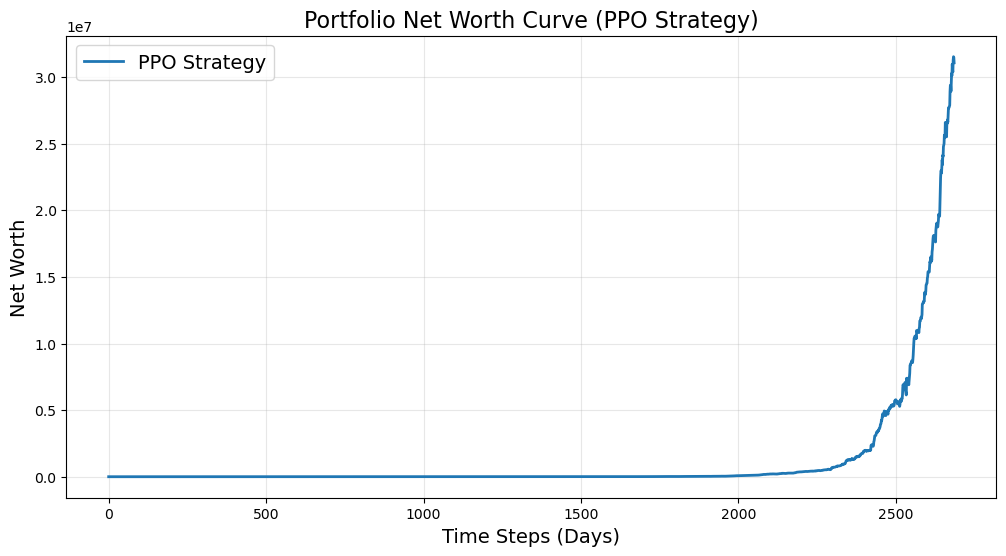

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(net_worths, label="PPO Strategy", linewidth=2)

plt.title("Portfolio Net Worth Curve (PPO Strategy)", fontsize=16)
plt.xlabel("Time Steps (Days)", fontsize=14)
plt.ylabel("Net Worth", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=14)

plt.show()


In [58]:
# Buy & Hold: equal weight in each stock from day 1
equal_weight = np.ones(env_test.num_stocks) / env_test.num_stocks
bh_net_worth = [1.0]

for t in range(len(env_test.dates) - 1):
    today_returns = env_test.raw_returns[t]
    bh_net_worth.append(bh_net_worth[-1] * (1 + np.dot(equal_weight, today_returns)))


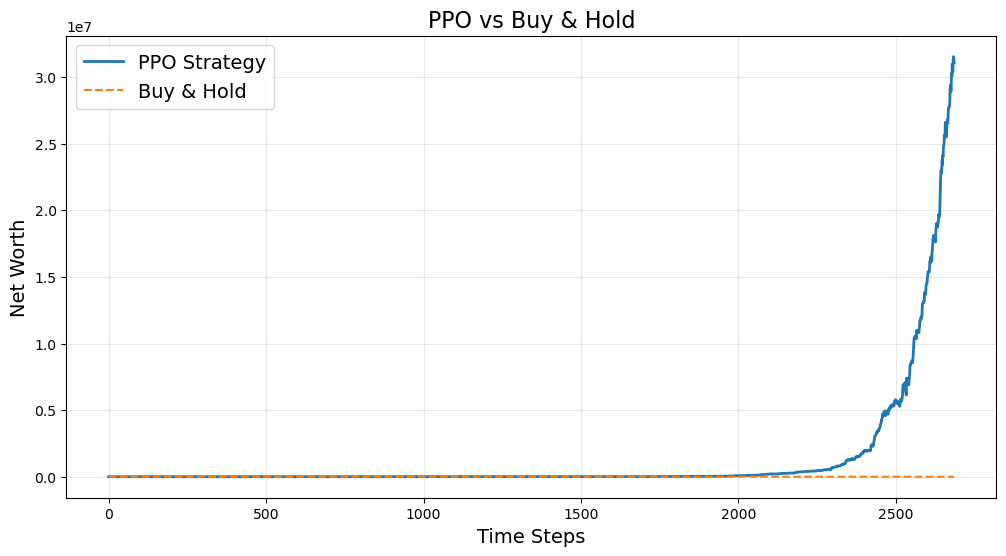

In [59]:
plt.figure(figsize=(12, 6))
plt.plot(net_worths, label="PPO Strategy", linewidth=2)
plt.plot(bh_net_worth, label="Buy & Hold", linestyle="--")

plt.title("PPO vs Buy & Hold", fontsize=16)
plt.xlabel("Time Steps", fontsize=14)
plt.ylabel("Net Worth", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=14)
plt.show()


In [62]:
x = yf.download("AAPL,NVDA", start="2010-01-01")
x.to_csv("AAPL_data.csv")

C:\Users\Bowen Ma\AppData\Local\Temp\ipykernel_3220\3063728553.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  x = yf.download("AAPL,NVDA", start="2010-01-01")
[*********************100%***********************]  2 of 2 completed


In [63]:
x

Price            Close                    High                     Low  \
Ticker            AAPL        NVDA        AAPL        NVDA        AAPL   
Date                                                                     
2010-01-04    6.418384    0.423830    6.433080    0.426810    6.369499   
2010-01-05    6.429479    0.430019    6.465768    0.434604    6.395588   
2010-01-06    6.327212    0.432770    6.454974    0.433687    6.320614   
2010-01-07    6.315514    0.424289    6.358101    0.432311    6.269627   
2010-01-08    6.357500    0.425206    6.358100    0.428185    6.269927   
...                ...         ...         ...         ...         ...   
2025-11-10  269.429993  199.050003  273.730011  199.940002  267.459991   
2025-11-11  275.250000  193.160004  275.910004  195.419998  269.799988   
2025-11-12  273.470001  193.800003  275.730011  195.889999  271.700012   
2025-11-13  272.950012  186.860001  276.700012  191.440002  272.089996   
2025-11-14  272.410004  190.169998  275.959991  191.009995  269.600006   

Price                         Open                 Volume             
Ticker            NVDA        AAPL        NVDA       AAPL       NVDA  
Date                                                                  
2010-01-04    0.415120    6.400989    0.424289  493729600  800204000  
2010-01-05    0.422226    6.436077    0.422226  601904800  728648000  
2010-01-06    0.425664    6.429481    0.429790  552160000  649168000  
2010-01-07    0.421080    6.350604    0.430478  477131200  547792000  
2010-01-08    0.418329    6.307115    0.420850  447610800  478168000  
...                ...         ...         ...        ...        ...  
2025-11-10  193.789993  268.959991  195.110001   41312400  198897100  
2025-11-11  191.300003  269.809998  195.160004   46208300  176483300  
2025-11-12  191.130005  275.000000  195.720001   48398000  154935300  
2025-11-13  183.850006  274.109985  191.050003   49602800  207423100  
2025-11-14  180.580002  271.049988  182.860001   47399300  186019700  

[3993 rows x 10 columns]